Downloading the dataset through Kaggle

In [1]:
#Install Kaggle
!pip install kaggle

In [2]:
#Upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (3).json


{'kaggle (3).json': b'{\r\n    "username": "int_token",\r\n    "key": "KGAT_8484ebae0581aa10e109f67d1f4ebf5a"\r\n}'}

In [3]:
# Create a kaggle directory
!mkdir -p ~/.kaggle

In [4]:
#Copy Kaggle.json file
!cp kaggle.json ~/.kaggle/

In [5]:
# Change permissions so the API can read it
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
ls -ltr ~/.kaggle

total 8
-rw------- 1 root root 38 May  6 08:59 access_token
-rw------- 1 root root 86 May  6 11:09 kaggle.json


In [7]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          20097        436                1  
prince7489/online-vs-offline-learning-efficiency-dataset            Online vs Offline Learning Efficiency Dataset             7365  2026-05-02 16:38:31.343000            886         25        0.9411765  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1867         48

In [26]:
#!/bin/bash
!kaggle datasets download bhavikjikadara/car-price-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/car-price-prediction-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.79k/3.79k [00:00<00:00, 4.60MB/s]



In [27]:
# Unzip the file
!unzip car-price-prediction-dataset.zip

Archive:  car-price-prediction-dataset.zip
  inflating: car_prediction_data.csv  


In [28]:
# List files to confirm it's there
!ls

 best_car_price_model.pkl	   'kaggle (1).json'
'car data.csv'			   'kaggle (2).json'
'CAR DETAILS FROM CAR DEKHO.csv'   'kaggle (3).json'
'Car details v3.csv'		    kaggle.json
'car details v4.csv'		    sample_data
 car_prediction_data.csv	    vehicle-dataset-from-cardekho.zip
 car-price-prediction-dataset.zip


Project Code

In [29]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [30]:
# Load Dataset
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [31]:
# About the Dataset
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())


(301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB
None
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.62

In [32]:
# Preprocessing
CURRENT_YEAR = 2026
df["Vehicle_Age"] = CURRENT_YEAR - df["Year"]

# Dropping unused columns
drop_cols = ["Year", "Car_Name"]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


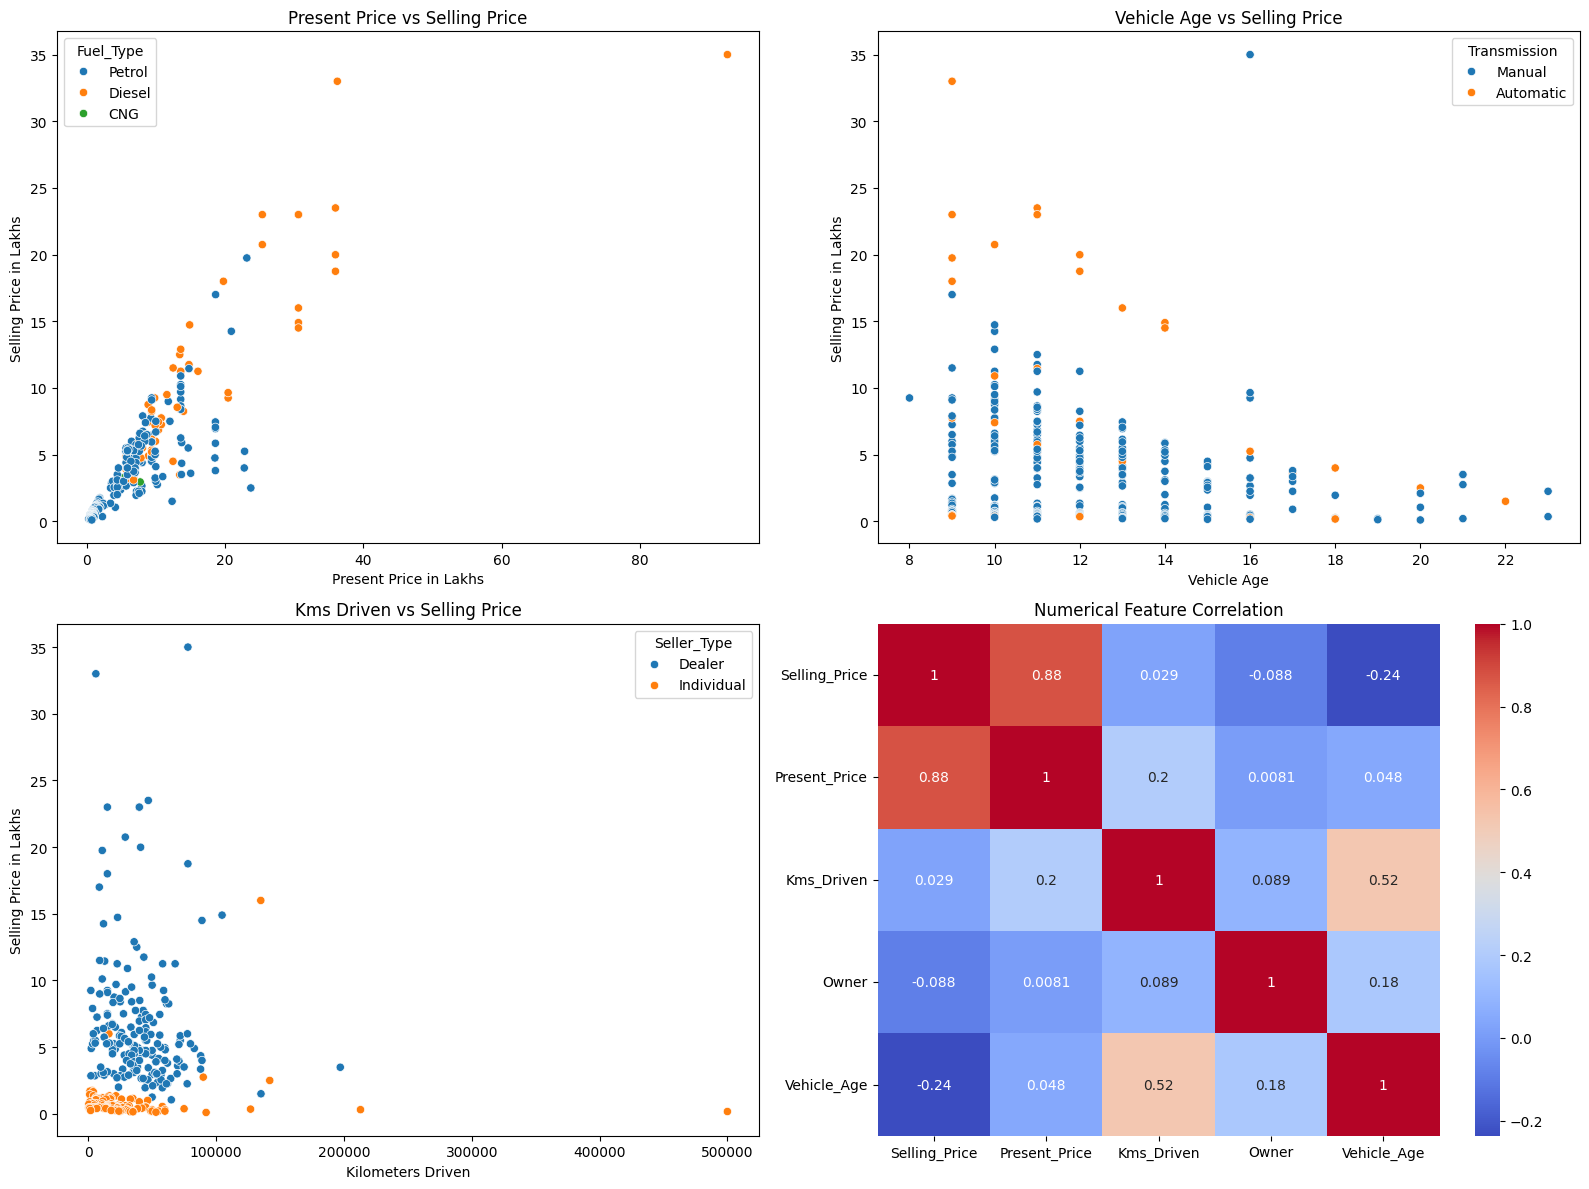

In [38]:
# Basic EDA

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Present Price vs Selling Price
sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price",
    hue="Fuel_Type",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Present Price vs Selling Price")
axes[0, 0].set_xlabel("Present Price in Lakhs")
axes[0, 0].set_ylabel("Selling Price in Lakhs")

# 2. Vehicle Age vs Selling Price
sns.scatterplot(
    data=df,
    x="Vehicle_Age",
    y="Selling_Price",
    hue="Transmission",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Vehicle Age vs Selling Price")
axes[0, 1].set_xlabel("Vehicle Age")
axes[0, 1].set_ylabel("Selling Price in Lakhs")

# 3. Kms Driven vs Selling Price
sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price",
    hue="Seller_Type",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Kms Driven vs Selling Price")
axes[1, 0].set_xlabel("Kilometers Driven")
axes[1, 0].set_ylabel("Selling Price in Lakhs")

# 4. Correlation Heatmap
numeric_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Owner", "Vehicle_Age"]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Numerical Feature Correlation")

plt.tight_layout()
plt.show()


In [39]:
# Features and Target

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)


Categorical: ['Fuel_Type', 'Seller_Type', 'Transmission']
Numerical: ['Present_Price', 'Kms_Driven', 'Owner', 'Vehicle_Age']


In [40]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [41]:
# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
# Model Comparison

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])
    trained_pipelines[name] = pipeline

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
).sort_values(by="R2 Score", ascending=False)

results_df

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.606525,0.927681,0.962641
1,Decision Tree,0.733770,1.130603,0.944509
0,Linear Regression,1.216226,1.865155,0.848981


In [43]:
# Select Best Model

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("Best Model:", best_model_name)


Best Model: Random Forest


In [44]:
# Save Pickle File

import pickle

with open("best_car_price_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully.")


Model saved successfully.


In [45]:
# Download Pickle from Colab
from google.colab import files

files.download("best_car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>